# `prim` — Prim MST 알고리즘 데모

[`algorithms/graph/prim.py`](prim.py) 는 textbook lazy Prim MST — min-heap 으로 MST 에서 가장 가까운 정점을 탐욕적으로 추가하며 `("add_edge", u, v, w)` / `("skip_edge", u, v, w)` 이벤트를 yield 한다.

[`algorithms/graph/trace.py`](trace.py) 의 `@trace` 데코레이터가 `prim.mst` helper 를 자동 부여한다. Kruskal 과 달리 시작 정점이 필요하다. 무방향 그래프 전용이며, 비연결 그래프에서는 시작 정점의 컴포넌트 MST 만 구한다.

In [1]:
import sys

sys.path.insert(0, '../..')

import core.graph as g
from algorithms.graph.prim import prim

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')


def show(graph, start):
    """원본 그래프 위에 start 에서 시작한 MST 간선을 강조."""
    return graph._to_graphviz(highlight=prim.mst(graph, start))

## 0. textbook 사용법

`prim(g, a)` — `("add_edge", u, v, w)` / `("skip_edge", u, v, w)` 이벤트 iterator. `prim.mst(g, a)` 로 MST `WeightedGraph` 를 바로 얻을 수 있다.

MST: WeightedGraph(undirected, V=5, E=4)


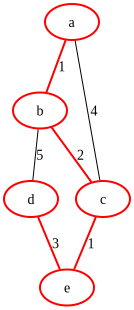

In [2]:
g0 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 1), (a, c, 4), (b, c, 2), (b, d, 5), (c, e, 1), (d, e, 3)]:
    g0.add_edge(u, v, w)

print('MST:', prim.mst(g0, a))
show(g0, a)

## 1. Path — `a -2- b -5- c -1- d`

이미 트리 구조 → 모든 간선이 MST 에 추가됨. Prim 은 `a` 에서 출발해 선형으로 확장.

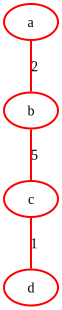

In [3]:
show(g.WeightedGraph(a - 2 - b - 5 - c - 1 - d), a)

## 2. 시작 정점 무관 — 같은 MST

```
a -3- b
a -1- c
a -7- d
b -2- c
b -1- d
c -5- d
```

시작 정점이 달라도 MST 는 동일 (`a-c(1)`, `b-d(1)`, `b-c(2)`, 총 비용 4).

start=a MST: WeightedGraph(undirected, V=4, E=3)


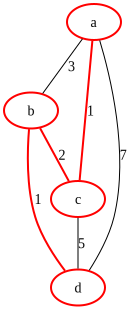

In [4]:
g2 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 3), (a, c, 1), (a, d, 7), (b, c, 2), (b, d, 1), (c, d, 5)]:
    g2.add_edge(u, v, w)

print('start=a MST:', prim.mst(g2, a))
show(g2, a)

start=d MST: WeightedGraph(undirected, V=4, E=3)


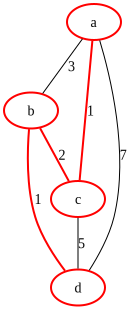

In [5]:
print('start=d MST:', prim.mst(g2, d))
show(g2, d)

## 3. Dense — 6-node 복합 그래프

```
a -2- b -5- d
a -6- c     |
b -3- e -1- f
c -8- e
c -4- f
d -7- f
```

Prim 이 `a` 에서 출발해 탐욕적으로 확장. MST 총 비용 15.

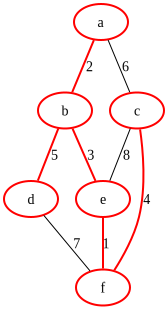

In [6]:
g3 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 2), (a, c, 6), (b, d, 5), (b, e, 3), (c, e, 8), (c, f, 4), (d, f, 7), (e, f, 1)]:
    g3.add_edge(u, v, w)

show(g3, a)

## 4. Kruskal vs Prim — 같은 그래프 비교

두 알고리즘이 동일한 MST 를 반환하는지 확인.

In [7]:
from algorithms.graph.kruskal import kruskal

mst_prim = prim.mst(g0, a)
mst_kruskal = kruskal.mst(g0)

print('prim MST edges:   ', sorted(mst_prim.to_edge_list(), key=lambda e: e[2]))
print('kruskal MST edges:', sorted(mst_kruskal.to_edge_list(), key=lambda e: e[2]))
print('isomorphic:', mst_prim.is_isomorphic_to(mst_kruskal))

prim MST edges:    [('a', 'b', 1), ('c', 'e', 1), ('b', 'c', 2), ('e', 'd', 3)]
kruskal MST edges: [('a', 'b', 1), ('c', 'e', 1), ('b', 'c', 2), ('e', 'd', 3)]
isomorphic: True


## 5. raw 이벤트 스트림

`prim(g, a)` 직접 소비 — `"add_edge"` / `"skip_edge"` 이벤트 출력.
`"skip_edge"` 는 도착 정점이 이미 MST 안에 있는 stale heap 항목이다.

In [8]:
for event in prim(g0, a):
    match event:
        case ('add_edge', u, v, w):
            print(f'  add   {u} -{w}- {v}')
        case ('skip_edge', u, v, w):
            print(f'  skip  {u} -{w}- {v}  (already in MST)')

  add   a -1- b
  add   b -2- c
  add   c -1- e
  add   e -3- d
  skip  a -4- c  (already in MST)
  skip  b -5- d  (already in MST)
